# Preprocessing and EDA for Acute Oral Toxicity Dataset

This notebook performs end-to-end preprocessing and exploratory data analysis (EDA) for an acute oral toxicity dataset, covering both single-compound and mixture (formulation) toxicity data.

Key Objectives

- Clean and standardize raw toxicity data

- Convert LD₅₀ values from mg/kg to −log₁₀(mol/kg) for chemically meaningful comparison

- Prepare separate datasets for:

    - single compounds

    - chemical mixtures (drug pairs)

- Handle duplicates and inconsistencies robustly

- Generate model-ready datasets for downstream GNN-based learning

- Perform basic EDA to understand toxicity distributions

In [79]:
!pip install rdkit

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit import RDLogger

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [81]:
file_path = '/content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_with_SMILES.csv'
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()
print(df.shape)
df.sample(5)

(16839, 21)


,Formulation Name,Chemical Name,CASRN,DTXSID,Percent Active,Mixture,Data Type,Assay,Endpoint,Response Modifier,...,Units,Species,Route,Sex,Reference,PMID,URL,Formulation ID,Record ID,SMILES
13536,Troysan V48,Diuron,330-54-1,DTXSID0020446,48.00,Y,In Vivo,Rat Acute Oral Toxicity,LD50,,...,mg/kg,Rat,Oral,Female,Studies submitted to EPA in support of pestici...,NaN,NaN,AcuteOralToxicity_PID_614,AcuteOralToxicity_21040,CN(C)C(=O)NC1=CC(=C(C=C1)Cl)Cl
3771,NaN,Methyl [(naphthalen-1-yl)oxy]acetate,1929-87-9,DTXSID10940963,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,,...,mg/kg,Rat,Oral,NaN,NaN,NaN,NaN,NaN,AcuteOralToxicity_3772,COC(=O)COC1=CC=CC2=CC=CC=C21
14894,Sativa IMX Max,Metalaxyl,57837-19-1,DTXSID6024175,0.58,Y,In Vivo,Rat Acute Oral Toxicity,EPA Classification,,...,NaN,Rat,Oral,Female,Studies submitted to EPA in support of pestici...,NaN,NaN,AcuteOralToxicity_PID_513,AcuteOralToxicity_20883,CC1=C(C(=CC=C1)C)N(C(C)C(=O)OC)C(=O)COC
12467,Clincher CA,Cyhalofop-butyl,122008-78-0,DTXSID701022032,29.60,Y,In Vivo,Rat Acute Oral Toxicity,LD50,,...,mg/kg,Rat,Oral,Female,Studies submitted to EPA in support of pestici...,NaN,NaN,AcuteOralToxicity_PID_139,AcuteOralToxicity_20232,CC(C(=O)O)OC1=CC=C(C=C1)OC2=C(C=C(C=C2)C#N)F
5192,NaN,Methyl parathion,298-00-0,DTXSID1020855,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,,...,mg/kg,Rat,Oral,Female,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_5193,COP(=S)(OC)OC1=CC=C(C=C1)[N+](=O)[O-]


## Basic normalization

In [82]:
# Standardize text columns for safer filtering
for col in ["Mixture", "Endpoint", "Units", "Species", "Route",
            "Chemical Name", "CASRN", "Formulation ID", "SMILES", "Response Modifier"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Restore NaN where string conversion created "nan"
df = df.replace({"nan": np.nan, "None": np.nan, "": np.nan})

# Handle Response Modifier (keep only exact values)
if "Response Modifier" in df.columns:
    df = df[
        (df["Response Modifier"].isna()) |
        (df["Response Modifier"] == "")
    ].copy()

# Numeric columns
for col in ["Response", "Percent Active"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,Formulation Name,Chemical Name,CASRN,DTXSID,Percent Active,Mixture,Data Type,Assay,Endpoint,Response Modifier,...,Units,Species,Route,Sex,Reference,PMID,URL,Formulation ID,Record ID,SMILES
0,NaN,1-Chloro-4-nitrobenzene,100-00-5,DTXSID5020281,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,NaN,...,mg/kg,Rat,Oral,Male,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_1,C1=CC(=CC=C1[N+](=O)[O-])Cl
1,NaN,1-Chloro-4-nitrobenzene,100-00-5,DTXSID5020281,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,NaN,...,mg/kg,Rat,Oral,NaN,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_2,C1=CC(=CC=C1[N+](=O)[O-])Cl
2,NaN,1-Chloro-4-nitrobenzene,100-00-5,DTXSID5020281,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,NaN,...,mg/kg,Rat,Oral,Male,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_3,C1=CC(=CC=C1[N+](=O)[O-])Cl
3,NaN,1-Chloro-4-nitrobenzene,100-00-5,DTXSID5020281,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,NaN,...,mg/kg,Rat,Oral,NaN,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_4,C1=CC(=CC=C1[N+](=O)[O-])Cl
4,NaN,1-Chloro-4-nitrobenzene,100-00-5,DTXSID5020281,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,NaN,...,mg/kg,Rat,Oral,Female,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_5,C1=CC(=CC=C1[N+](=O)[O-])Cl


In [83]:
df.shape

(12560, 21)

## Helper functions

The helper functions are designed to convert toxicity values from mg/kg to −log₁₀(mol/kg)

LD₅₀ values are originally reported in mg/kg, which represents the mass of a substance required per unit body weight to cause toxicity. However, molecules differ in size, so comparing toxicity based only on mass can be misleading.


To address this, the values are converted to molar units (mol/kg) using molecular weight:

	​mol/kg= LD₅₀ (mg/kg) / [1000 × MW (g/mol)]


This transformation expresses toxicity in terms of the number of molecules, which is more appropriate for chemical modeling.

In [84]:
# suppress RDKit warnings
RDLogger.DisableLog('rdApp.*')

In [85]:
def parse_smiles(smiles):
    """
    Safely parse a SMILES string with sanitization.
    Returns an RDKit molecule object or None if invalid.
    """
    try:
        if pd.isna(smiles):
            return None
        smiles = str(smiles).strip()
        if smiles == "":
            return None

        mol = Chem.MolFromSmiles(smiles, sanitize=True)
        return mol
    except:
        return None


def is_valid_smiles(smiles):
    """
    Check whether a SMILES string is valid and can be parsed by RDKit.
    """
    return parse_smiles(smiles) is not None

def canonicalize_smiles(smiles):
    """
    Convert a valid SMILES string to canonical SMILES.
    Returns NaN if invalid.
    """
    mol = parse_smiles(smiles)
    if mol is None:
        return np.nan
    try:
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return np.nan

def smiles_to_mw(smiles):
    """
    Return molecular weight from a valid SMILES string.
    Returns NaN if parsing fails.
    """
    mol = parse_smiles(smiles)
    if mol is None:
        return np.nan

    try:
        return Descriptors.MolWt(mol)
    except:
        return np.nan


def mgkg_to_neglog_molkg_single(smiles, ld50_mgkg):
    """
    Convert single-compound LD50 from mg/kg to -log10(mol/kg).
    """
    try:
        if pd.isna(smiles) or pd.isna(ld50_mgkg) or ld50_mgkg <= 0:
            return np.nan

        mw = smiles_to_mw(smiles)
        if pd.isna(mw) or mw <= 0:
            return np.nan

        molkg = (ld50_mgkg / 1000.0) / mw
        if molkg <= 0:
            return np.nan

        return -np.log10(molkg)
    except:
        return np.nan


def mixture_moles_per_kg_from_components(ld50_mgkg, percent_list, mw_list):
    """
    Compute mol/kg for a mixture formulation using:

    mol/kg = (ld50_mgkg / 1000) * sum(f_i / MW_i)

    where f_i = percent_active_i / 100
    """
    try:
        if pd.isna(ld50_mgkg) or ld50_mgkg <= 0:
            return np.nan

        total = 0.0
        valid_count = 0

        for p, mw in zip(percent_list, mw_list):
            if pd.isna(p) or pd.isna(mw) or p <= 0 or mw <= 0:
                continue
            f = p / 100.0
            total += (f / mw)
            valid_count += 1

        if valid_count == 0 or total <= 0:
            return np.nan

        molkg = (ld50_mgkg / 1000.0) * total
        if molkg <= 0:
            return np.nan

        return molkg
    except:
        return np.nan


def mgkg_to_neglog_molkg_mixture(ld50_mgkg, percent_list, mw_list):
    """
    Convert mixture LD50 from mg/kg to -log10(mol/kg)
    using total moles of known active ingredients.
    """
    molkg = mixture_moles_per_kg_from_components(ld50_mgkg, percent_list, mw_list)
    if pd.isna(molkg) or molkg <= 0:
        return np.nan
    return -np.log10(molkg)


def effective_mixture_mw(percent_list, mw_list):
    """
    Optional diagnostic value.
    Returns effective MW of the active mixture using harmonic mean:

    MW_eff = 1 / sum(w_i / MW_i)

    where w_i are normalized active mass fractions among known active ingredients.
    This is useful for interpretation, not necessary for conversion.
    """
    pairs = []
    for p, mw in zip(percent_list, mw_list):
        if pd.notna(p) and pd.notna(mw) and p > 0 and mw > 0:
            pairs.append((p, mw))

    if len(pairs) == 0:
        return np.nan

    total_p = sum(p for p, _ in pairs)
    if total_p <= 0:
        return np.nan

    denom = sum((p / total_p) / mw for p, mw in pairs)
    if denom <= 0:
        return np.nan

    return 1.0 / denom

## Canonicalize SMILES before any preprocessing

In [86]:
# Keep original SMILES for reference
df["SMILES_original"] = df["SMILES"]

# Validate SMILES
df["Valid_SMILES"] = df["SMILES"].apply(is_valid_smiles)

# Create canonical SMILES only for valid structures
df["SMILES_canonical"] = df["SMILES"].apply(canonicalize_smiles)

# Replace working SMILES column with canonical version
df["SMILES"] = df["SMILES_canonical"]

print("Total rows:", len(df))
print("Rows with valid SMILES:", df["Valid_SMILES"].sum())
print("Rows with invalid SMILES:", (~df["Valid_SMILES"].fillna(False)).sum())

df[["SMILES_original", "SMILES_canonical", "Valid_SMILES"]].sample(5)

Total rows: 12560
Rows with valid SMILES: 12422
Rows with invalid SMILES: 138


,SMILES_original,SMILES_canonical,Valid_SMILES
7975,CNCCCN1C2=CC=CC=C2CCC3=CC=CC=C31.Cl,CNCCCN1c2ccccc2CCc2ccccc21.Cl,True
9365,C(C(=O)N)Br,NC(=O)CBr,True
805,C1=CC(=CC(=C1)O)O,Oc1cccc(O)c1,True
13846,COC1=CC(=NC(=N1)OC2=C(C(=CC=C2)OC3=NC(=CC(=N3)...,COc1cc(OC)nc(Oc2cccc(Oc3nc(OC)cc(OC)n3)c2C(=O)...,True
1200,CC(C)NCC(COC1=CC=C(C=C1)C2=C(C(OC3=C2C=CC(=C3)...,COc1ccc2c(c1)OC(C)(C)C(c1ccccc1)=C2c1ccc(OCC(O...,True


## Preprocess single-compound dataset

In [87]:
single_raw = df[
    (df["Mixture"].str.upper() == "N") &
    (df["Endpoint"].str.upper() == "LD50") &
    (df["Response"].notna()) &
    (df["CASRN"].notna()) &
    (df["SMILES"].notna()) &
    (df["Units"].str.lower() == "mg/kg") &
    (df["Species"].str.lower() == "rat") &
    (df["Route"].str.lower() == "oral")
].copy()

# Keep only positive numeric responses
single_raw["Response"] = pd.to_numeric(single_raw["Response"], errors="coerce")
single_raw = single_raw[single_raw["Response"] > 0].copy()

# Compute MW from canonical SMILES
single_raw["MW"] = single_raw["SMILES"].apply(smiles_to_mw)
single_raw = single_raw[single_raw["MW"].notna()].copy()

print("Single raw rows after exact-value filtering:", len(single_raw))
single_raw.sample(5)

Single raw rows after exact-value filtering: 8675


,Formulation Name,Chemical Name,CASRN,DTXSID,Percent Active,Mixture,Data Type,Assay,Endpoint,Response Modifier,...,Reference,PMID,URL,Formulation ID,Record ID,SMILES,SMILES_original,Valid_SMILES,SMILES_canonical,MW
4907,NaN,"O-(4-Bromo-2,5-dichlorophenyl) O-methyl ethylp...",2720-19-6,DTXSID90949934,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,NaN,...,NaN,NaN,NaN,NaN,AcuteOralToxicity_4908,CCP(=S)(OC)Oc1cc(Cl)c(Br)cc1Cl,CCP(=S)(OC)OC1=CC(=C(C=C1Cl)Br)Cl,True,CCP(=S)(OC)Oc1cc(Cl)c(Br)cc1Cl,364.028
6682,NaN,13-cis Retinoic acid,4759-48-2,DTXSID4023177,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,NaN,...,NLM ChemIDplus TEST (undated),NaN,https://chem.nlm.nih.gov/chemidplus/,NaN,AcuteOralToxicity_6684,CC(C=CC1=C(C)CCCC1(C)C)=CC=CC(C)=CC(=O)O,CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC(=O)O)C)C,True,CC(C=CC1=C(C)CCCC1(C)C)=CC=CC(C)=CC(=O)O,300.442
6344,NaN,N-(3-Chloroallyl)hexaminium chloride,4080-31-3,DTXSID5024760,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,NaN,...,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_6346,ClC=CC[N+]12CN3CN(CN(C3)C1)C2.[Cl-],C1N2CN3CN1C[N+](C2)(C3)CC=CCl.[Cl-],True,ClC=CC[N+]12CN3CN(CN(C3)C1)C2.[Cl-],251.161
399,NaN,gamma-Nonanolactone,104-61-0,DTXSID0034229,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,NaN,...,NLM Hazardous Substances Data Bank (undated),NaN,https://pubchem.ncbi.nlm.nih.gov/,NaN,AcuteOralToxicity_400,CCCCCC1CCC(=O)O1,CCCCCC1CCC(=O)O1,True,CCCCCC1CCC(=O)O1,156.225
6444,NaN,"Benzimidazole, 4,7-dichloro-2-(trifluoromethyl)-",4228-89-1,DTXSID00195107,NaN,N,In Vivo,Rat Acute Oral Toxicity,LD50,NaN,...,NLM ChemIDplus TEST (undated),NaN,https://chem.nlm.nih.gov/chemidplus/,NaN,AcuteOralToxicity_6446,FC(F)(F)c1nc2c(Cl)ccc(Cl)c2[nH]1,C1=CC(=C2C(=C1Cl)NC(=N2)C(F)(F)F)Cl,True,FC(F)(F)c1nc2c(Cl)ccc(Cl)c2[nH]1,255.026


## Aggregate duplicate single-compound records using median

In [88]:
single_processed = single_raw.groupby("CASRN", as_index=False).agg({
    "Chemical Name": "first",
    "SMILES": "first",
    "MW": "first",
    "Response": "median"
})

single_processed = single_processed.rename(columns={
    "Chemical Name": "Drug",
    "Response": "LD50_mg_per_kg"
})

single_processed["neglog_molkg"] = single_processed.apply(
    lambda x: mgkg_to_neglog_molkg_single(x["SMILES"], x["LD50_mg_per_kg"]),
    axis=1
)

single_processed = single_processed.dropna(subset=["neglog_molkg"]).reset_index(drop=True)

print("Single processed rows:", len(single_processed))
single_processed.sample(5)

Single processed rows: 6719


,CASRN,Drug,SMILES,MW,LD50_mg_per_kg,neglog_molkg
2939,31643-49-9,"1,2-Benzenedicarbonitrile, 4-nitro-",N#Cc1ccc([N+](=O)[O-])cc1C#N,173.131,850.0,2.308956
1997,2039-87-4,2-Chlorostyrene,C=Cc1ccccc1Cl,138.597,5200.0,1.425750
4990,63716-32-5,"6-Ethoxy-2,3,4,9-tetrahydro-1H-carbazol-7-amin...",CCOc1cc2c(cc1N)[NH2+]C1=C2CCCC1.[Cl-],266.772,810.0,2.517655
695,117617-70-6,Octyldichloropropyl phosphate,CCCCCCCCOP(=O)(O)OCCC(Cl)Cl,321.181,10300.0,1.493913
2907,311-47-7,"Phosphoric acid, 2-chloroethenyl diethyl ester",CCOP(=O)(OC=CCl)OCC,214.585,7.0,4.486501


## Save single-compound datasets

In [89]:
single_output_path = '/content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_processed.csv'
single_processed.to_csv(single_output_path, index=False)
print(f"Saved processed single dataset to {single_output_path}")

single_model_ready = single_processed[["SMILES", "neglog_molkg"]].copy()
single_model_ready_path = '/content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_model_ready.csv'
single_model_ready.to_csv(single_model_ready_path, index=False)
print(f"Saved single model-ready dataset to {single_model_ready_path}")

Saved processed single dataset to /content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_processed.csv
Saved single model-ready dataset to /content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_model_ready.csv


## EDA for single-compound dataset

Single dataset size: 6719
count    6719.000000
mean        2.532485
std         0.893758
min         0.291207
25%         1.913000
50%         2.387459
75%         2.984170
max         7.634402
Name: neglog_molkg, dtype: float64


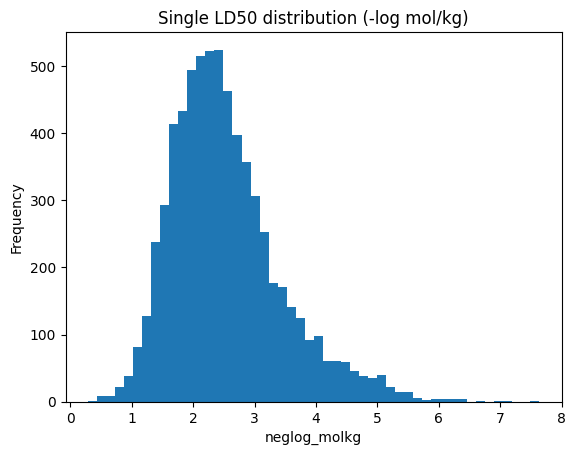

In [90]:
print("Single dataset size:", len(single_model_ready))
print(single_model_ready["neglog_molkg"].describe())

import matplotlib.pyplot as plt

plt.hist(single_model_ready["neglog_molkg"], bins=50)
plt.title("Single LD50 distribution (-log mol/kg)")
plt.xlabel("neglog_molkg")
plt.ylabel("Frequency")
plt.show()

| neglog_molkg range | Interpretation          |
| ------------------ | ----------------------- |
| **< 1.5**          | very low toxicity       |
| **1.5 to 2.0**     | low toxicity            |
| **2.0 to 2.5**     | moderate toxicity       |
| **2.5 to 3.0**     | high toxicity           |
| **3.0 to 3.5**     | very high toxicity      |
| **> 3.5**          | extremely high toxicity |


## Build lookup from single-compound dataset
This fetch:

- SMILES

- LD50 of individual compounds

In [91]:
single_lookup = single_processed.set_index("CASRN")[["Drug", "SMILES", "MW", "LD50_mg_per_kg", "neglog_molkg"]].to_dict("index")
print("Lookup size:", len(single_lookup))

Lookup size: 6719


## Extract mixture formulations

In [92]:
mix_df = df[
    (df["Mixture"].str.upper() == "Y") &
    (df["Formulation ID"].notna())
].copy()

print("Mixture raw rows:", len(mix_df))
mix_df.sample(5)

Mixture raw rows: 3825


,Formulation Name,Chemical Name,CASRN,DTXSID,Percent Active,Mixture,Data Type,Assay,Endpoint,Response Modifier,...,Sex,Reference,PMID,URL,Formulation ID,Record ID,SMILES,SMILES_original,Valid_SMILES,SMILES_canonical
14211,Fluazinam,Fluazinam,79622-59-6,DTXSID7032551,96.8,Y,In Vivo,Rat Acute Oral Toxicity,EPA Classification,NaN,...,Female,Studies submitted to EPA in support of pestici...,NaN,NaN,AcuteOralToxicity_PID_256,AcuteOralToxicity_20432,O=[N+]([O-])c1cc(C(F)(F)F)c(Cl)c([N+](=O)[O-])...,C1=C(C=NC(=C1Cl)NC2=C(C=C(C(=C2[N+](=O)[O-])Cl...,True,O=[N+]([O-])c1cc(C(F)(F)F)c(Cl)c([N+](=O)[O-])...
13174,Propiconazole(93%),Propiconazole,60207-90-1,DTXSID8024280,93.0,Y,In Vivo,Rat Acute Oral Toxicity,LD50,NaN,...,Male,Studies submitted to EPA in support of pestici...,NaN,NaN,AcuteOralToxicity_PID_458,AcuteOralToxicity_20791,CCCC1COC(Cn2cncn2)(c2ccc(Cl)cc2Cl)O1,CCCC1COC(O1)(CN2C=NC=N2)C3=C(C=C(C=C3)Cl)Cl,True,CCCC1COC(Cn2cncn2)(c2ccc(Cl)cc2Cl)O1
13625,241-GOL Acrobat MZ WDG Fungicide,Dimethomorph,110488-70-5,DTXSID7034545,9.0,Y,In Vivo,Rat Acute Oral Toxicity,EPA Classification,NaN,...,NaN,Studies submitted to EPA in support of pestici...,NaN,NaN,AcuteOralToxicity_PID_002,AcuteOralToxicity_20002,COc1ccc(C(=CC(=O)N2CCOCC2)c2ccc(Cl)cc2)cc1OC,COC1=C(C=C(C=C1)C(=CC(=O)N2CCOCC2)C3=CC=C(C=C3...,True,COc1ccc(C(=CC(=O)N2CCOCC2)c2ccc(Cl)cc2)cc1OC
16425,Rave Herbicide,Dicamba-sodium,1982-69-0,DTXSID8027450,50.0,Y,In Vivo,Rat Acute Oral Toxicity,GHS Classification,NaN,...,Female,Studies submitted to EPA in support of pestici...,NaN,NaN,AcuteOralToxicity_PID_478,AcuteOralToxicity_20831,COc1c(Cl)ccc(Cl)c1C(=O)[O-].[Na+],COC1=C(C=CC(=C1C(=O)[O-])Cl)Cl.[Na+],True,COc1c(Cl)ccc(Cl)c1C(=O)[O-].[Na+]
15109,DuPont Treoris Fungicide,Chlorothalonil,1897-45-6,DTXSID0020319,22.3,Y,In Vivo,Rat Acute Oral Toxicity,EPA Classification,NaN,...,Female,Studies submitted to EPA in support of pestici...,NaN,NaN,AcuteOralToxicity_PID_607,AcuteOralToxicity_21026,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,C(#N)C1=C(C(=C(C(=C1Cl)Cl)Cl)C#N)Cl,True,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl


## Reconstruct mixtures from formulation groups

In [93]:
grouped = mix_df.groupby("Formulation ID")

mixture_rows = []

for fid, group in grouped:
    group = group.copy()

    # Keep rows with valid component identity
    comp_group = group.dropna(subset=["CASRN", "Chemical Name", "SMILES", "Percent Active"]).copy()
    comp_group = comp_group[comp_group["Percent Active"] > 0].copy()

    if len(comp_group) == 0:
        continue

    # Deduplicate same component inside formulation
    comp_group["MW_component"] = comp_group["SMILES"].apply(smiles_to_mw)
    comp_group = comp_group.dropna(subset=["MW_component"]).copy()

    comp_group = comp_group.groupby("CASRN", as_index=False).agg({
        "Chemical Name": "first",
        "SMILES": "first",
        "Percent Active": "median",
        "MW_component": "first"
    })

    # Keep only formulations with at least 2 compounds
    if len(comp_group) < 2:
        continue

    # Sort for stable ordering
    comp_group = comp_group.sort_values(by=["CASRN"]).reset_index(drop=True)

    # Get formulation LD50 rows
    ld50_rows = group[
        (group["Endpoint"].str.upper() == "LD50") &
        (group["Response"].notna()) &
        (group["Units"].str.lower() == "mg/kg") &
        (group["Species"].str.lower() == "rat") &
        (group["Route"].str.lower() == "oral")
    ].copy()

    if len(ld50_rows) == 0:
        continue

    mixture_ld50 = ld50_rows["Response"].median()

    # For now keep only first 2 components for dual-input GNN
    compA = comp_group.iloc[0]
    compB = comp_group.iloc[1]

    casA = compA["CASRN"]
    casB = compB["CASRN"]

    smiles_A = compA["SMILES"]
    smiles_B = compB["SMILES"]

    mw_A = compA["MW_component"]
    mw_B = compB["MW_component"]

    percent_A = compA["Percent Active"]
    percent_B = compB["Percent Active"]

    # Use all known active components in formulation for accurate mixture conversion
    all_percents = comp_group["Percent Active"].tolist()
    all_mws = comp_group["MW_component"].tolist()

    total_active_percent = np.nansum(all_percents)
    mixture_mw_eff = effective_mixture_mw(all_percents, all_mws)
    mix_neglog = mgkg_to_neglog_molkg_mixture(mixture_ld50, all_percents, all_mws)

    # Individual compound toxicity from single-compound lookup
    ld50_A = single_lookup.get(casA, {}).get("LD50_mg_per_kg", np.nan)
    ld50_B = single_lookup.get(casB, {}).get("LD50_mg_per_kg", np.nan)

    neglog_A = single_lookup.get(casA, {}).get("neglog_molkg", np.nan)
    neglog_B = single_lookup.get(casB, {}).get("neglog_molkg", np.nan)

    mixture_rows.append({
        "Formulation_ID": fid,
        "DrugA": compA["Chemical Name"],
        "DrugB": compB["Chemical Name"],
        "CASRN_A": casA,
        "CASRN_B": casB,
        "SMILES_A": smiles_A,
        "SMILES_B": smiles_B,
        "MW_A": mw_A,
        "MW_B": mw_B,
        "Percent_Active_A": percent_A,
        "Percent_Active_B": percent_B,
        "Total_Active_Percent_Known": total_active_percent,
        "Known_Component_Count": len(comp_group),
        "Effective_Mixture_MW_ActiveOnly": mixture_mw_eff,
        "LD50_A_mg_per_kg": ld50_A,
        "LD50_B_mg_per_kg": ld50_B,
        "neglog_A": neglog_A,
        "neglog_B": neglog_B,
        "Mixture_LD50_mg_per_kg": mixture_ld50,
        "Mixture_neglog_molkg": mix_neglog
    })

mixture_raw_processed = pd.DataFrame(mixture_rows)

print("Mixture formulation rows before final cleaning:", len(mixture_raw_processed))
mixture_raw_processed.sample(5)

Mixture formulation rows before final cleaning: 74


,Formulation_ID,DrugA,DrugB,CASRN_A,CASRN_B,SMILES_A,SMILES_B,MW_A,MW_B,Percent_Active_A,Percent_Active_B,Total_Active_Percent_Known,Known_Component_Count,Effective_Mixture_MW_ActiveOnly,LD50_A_mg_per_kg,LD50_B_mg_per_kg,neglog_A,neglog_B,Mixture_LD50_mg_per_kg,Mixture_neglog_molkg
63,AcuteOralToxicity_PID_591,Fludioxonil,Thiabendazole,131341-86-1,148-79-8,N#Cc1c[nH]cc1-c1cccc2c1OC(F)(F)O2,c1ccc2[nH]c(-c3cscn3)nc2c1,248.188,201.254,1.12,2.13,27.56,4,279.263838,NaN,2590.0,NaN,1.890445,3129.0,2.510330
28,AcuteOralToxicity_PID_360,Imidacloprid,Bifenthrin,138261-41-3,82657-04-3,O=[N+]([O-])N=C1NCCN1Cc1ccc(Cl)nc1,Cc1c(COC(=O)C2C(C=C(Cl)C(F)(F)F)C2(C)C)cccc1-c...,255.665,422.874,10.80,21.65,32.45,2,347.281448,NaN,54.5,NaN,3.889814,175.0,3.786429
65,AcuteOralToxicity_PID_612,"1,2-Benzisothiazolin-3-one","1,3-Dimethylol-5,5-dimethylhydantoin",2634-33-5,6440-58-0,O=c1[nH]sc2ccccc12,CC1(C)C(=O)N(CO)C(=O)N1CO,151.190,188.183,10.40,13.40,27.00,3,163.270862,1020.0,2890.0,2.170923,1.813683,1367.0,2.645776
54,AcuteOralToxicity_PID_535,"2,4-D-dimethylammonium",Triclopyr,2008-39-1,55335-06-3,CNC.O=C(O)COc1ccc(Cl)cc1Cl,O=C(O)COc1nc(Cl)c(Cl)cc1Cl,266.124,256.472,20.96,9.04,30.00,2,263.139915,764.0,679.5,2.541991,2.576850,5000.0,2.244095
0,AcuteOralToxicity_PID_030,Fludioxonil,Azoxystrobin,131341-86-1,131860-33-8,N#Cc1c[nH]cc1-c1cccc2c1OC(F)(F)O2,COC=C(C(=O)OC)c1ccccc1Oc1cc(Oc2ccccc2C#N)ncn1,248.188,403.394,0.80,0.32,31.52,5,282.890860,NaN,NaN,NaN,NaN,5000.0,2.254063


**Mixture conversion (mg/kg to -log₁₀(mol/kg))**

For mixtures, a simple molecular weight is not sufficient because multiple components contribute to the total dose. Therefore, the conversion is based on the combined molar contribution of all active components.

The total molar dose is calculated as:

	mol/kg = (𝐷 / 1000) × ∑ (𝑓𝑖 / 𝑀𝑊𝑖)

where:

*  𝐷 is the mixture LD₅₀ in mg/kg

*  𝑓𝑖 is the mass fraction of component 𝑖 (derived from Percent Active)

*  𝑀𝑊𝑖 is the molecular weight of component 𝑖


'*Percent Active* ' indicates the proportion of each chemical in a formulation (mixture). - “How much of this compound is present in the mixture (by mass %)”


## Final cleaning for mixture dataset

In [94]:
mixture_processed = mixture_raw_processed.dropna(subset=[
    "SMILES_A",
    "SMILES_B",
    "Mixture_LD50_mg_per_kg",
    "Mixture_neglog_molkg"
]).copy()

print("Mixture processed rows:", len(mixture_processed))
mixture_processed.sample(5)

Mixture processed rows: 74


,Formulation_ID,DrugA,DrugB,CASRN_A,CASRN_B,SMILES_A,SMILES_B,MW_A,MW_B,Percent_Active_A,Percent_Active_B,Total_Active_Percent_Known,Known_Component_Count,Effective_Mixture_MW_ActiveOnly,LD50_A_mg_per_kg,LD50_B_mg_per_kg,neglog_A,neglog_B,Mixture_LD50_mg_per_kg,Mixture_neglog_molkg
10,AcuteOralToxicity_PID_128,"2,4-D-dimethylammonium",Dicamba-dimethylammonium,2008-39-1,2300-66-5,CNC.O=C(O)COc1ccc(Cl)cc1Cl,CNC.COc1c(Cl)ccc(Cl)c1C(=O)O,266.124,266.124,4.74,0.53,6.50,4,266.303324,764.0,2629.0,2.541991,2.005293,1750.0,3.369425
31,AcuteOralToxicity_PID_386,Piperonyl butoxide,Permethrin,51-03-6,52645-53-1,CCCCOCCOCCOCc1cc2c(cc1CCC)OCO2,CC1(C)C(C=C(Cl)Cl)C1C(=O)OCc1cccc(Oc2ccccc2)c1,338.444,391.294,27.50,6.25,36.50,3,360.849119,6150.0,950.0,1.740612,2.614780,1750.0,2.751995
38,AcuteOralToxicity_PID_451,Bifenazate,Abamectin,149877-41-8,71751-41-2,COc1ccc(-c2ccccc2)cc1NNC(=O)OC(C)C,CCC(C)C1OC2(C=CC1C)CC1CC(CC=C(C)C(OC3CC(OC)C(O...,300.358,1732.153,43.20,2.20,45.40,2,312.890983,NaN,NaN,NaN,NaN,310.2,3.346695
63,AcuteOralToxicity_PID_591,Fludioxonil,Thiabendazole,131341-86-1,148-79-8,N#Cc1c[nH]cc1-c1cccc2c1OC(F)(F)O2,c1ccc2[nH]c(-c3cscn3)nc2c1,248.188,201.254,1.12,2.13,27.56,4,279.263838,NaN,2590.0,NaN,1.890445,3129.0,2.510330
19,AcuteOralToxicity_PID_243,Carfentrazone-ethyl,Fluthiacet-methyl,128639-02-1,149253-65-6,CCOC(=O)C(Cl)Cc1cc(-n2nc(C)n(C(F)F)c2=O)c(F)cc1Cl,O=C(O)CSc1cc(N=c2sc(=O)n3n2CCCC3)c(F)cc1Cl,412.195,389.861,19.91,4.79,24.70,2,407.666026,NaN,NaN,NaN,NaN,3129.0,2.722202


## Handle duplicate mixture pairs using canonical SMILES pair key

In [95]:
mixture_processed["PairKey"] = mixture_processed.apply(
    lambda x: "||".join(sorted([x["SMILES_A"], x["SMILES_B"]])),
    axis=1
)

mixture_agg = mixture_processed.groupby("PairKey", as_index=False).agg({
    "Formulation_ID": "first",
    "DrugA": "first",
    "DrugB": "first",
    "CASRN_A": "first",
    "CASRN_B": "first",
    "SMILES_A": "first",
    "SMILES_B": "first",
    "MW_A": "first",
    "MW_B": "first",
    "Percent_Active_A": "median",
    "Percent_Active_B": "median",
    "Total_Active_Percent_Known": "median",
    "Known_Component_Count": "median",
    "Effective_Mixture_MW_ActiveOnly": "median",
    "LD50_A_mg_per_kg": "median",
    "LD50_B_mg_per_kg": "median",
    "neglog_A": "median",
    "neglog_B": "median",
    "Mixture_LD50_mg_per_kg": "median",
    "Mixture_neglog_molkg": "median"
}).reset_index(drop=True)

print("Mixture unique pairs after aggregation:", len(mixture_agg))
mixture_agg.sample(5)

Mixture unique pairs after aggregation: 62


,PairKey,Formulation_ID,DrugA,DrugB,CASRN_A,CASRN_B,SMILES_A,SMILES_B,MW_A,MW_B,...,Percent_Active_B,Total_Active_Percent_Known,Known_Component_Count,Effective_Mixture_MW_ActiveOnly,LD50_A_mg_per_kg,LD50_B_mg_per_kg,neglog_A,neglog_B,Mixture_LD50_mg_per_kg,Mixture_neglog_molkg
4,CC(=O)OO||OO,AcuteOralToxicity_PID_657,Hydrogen Peroxide,Peracetic Acid,7722-84-1,79-21-0,OO,CC(=O)OO,34.014,76.051,...,0.300,5.90,2.0,34.997637,NaN,219.5,NaN,2.539670,3129.0,2.277781
11,CC(C)C1CCC(Cc2ccc(Cl)cc2)C1(O)Cn1cncn1||CC1=C(...,AcuteOralToxicity_PID_640,Ipconazole,Carboxin,125225-28-7,5234-68-4,CC(C)C1CCC(Cc2ccc(Cl)cc2)C1(O)Cn1cncn1,CC1=C(C(=O)Nc2ccccc2)SCCO1,333.863,235.308,...,35.530,37.75,2.0,239.465082,NaN,2588.0,NaN,1.958672,1750.0,2.559287
43,CN(C)C(=O)Nc1ccc(Cl)c(Cl)c1||COC(=O)Nc1nc2cccc...,AcuteOralToxicity_PID_448,Carbendazim,Diuron,10605-21-7,330-54-1,COC(=O)Nc1nc2ccccc2[nH]1,CN(C)C(=O)Nc1ccc(Cl)c(Cl)c1,191.190,233.098,...,15.000,27.00,3.0,221.135958,6400.0,NaN,1.475285,NaN,4958.0,2.217989
27,CC1(C)C(C=C(Cl)Cl)C1C(=O)OCc1cccc(Oc2ccccc2)c1...,AcuteOralToxicity_PID_386,Piperonyl butoxide,Permethrin,51-03-6,52645-53-1,CCCCOCCOCCOCc1cc2c(cc1CCC)OCO2,CC1(C)C(C=C(Cl)Cl)C1C(=O)OCc1cccc(Oc2ccccc2)c1,338.444,391.294,...,5.125,31.25,3.0,360.555095,6150.0,950.0,1.740612,2.614780,1750.0,2.825300
18,CC1(C)C(=O)N(CO)C(=O)N1CO||O=c1[nH]sc2ccccc12,AcuteOralToxicity_PID_612,"1,2-Benzisothiazolin-3-one","1,3-Dimethylol-5,5-dimethylhydantoin",2634-33-5,6440-58-0,O=c1[nH]sc2ccccc12,CC1(C)C(=O)N(CO)C(=O)N1CO,151.190,188.183,...,13.400,27.00,3.0,163.270862,1020.0,2890.0,2.170923,1.813683,1367.0,2.645776


## Save mixture datasets

In [96]:
mixture_output_path = '/content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_mixture_processed.csv'
mixture_agg.to_csv(mixture_output_path, index=False)
print(f"Saved processed mixture dataset to {mixture_output_path}")

# Main model-ready dataset for merging with the other Phase 4 dataset
mixture_model_ready = mixture_agg[[
    "SMILES_A",
    "SMILES_B",
    "Mixture_neglog_molkg"
]].copy()

mixture_model_ready_path = '/content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_mixture_model_ready.csv'
mixture_model_ready.to_csv(mixture_model_ready_path, index=False)
print(f"Saved mixture model-ready dataset to {mixture_model_ready_path}")

# Optional extended version with formulation ratio features
mixture_model_ready_extended = mixture_agg[[
    "SMILES_A",
    "SMILES_B",
    "Percent_Active_A",
    "Percent_Active_B",
    "Mixture_neglog_molkg"
]].copy()

mixture_model_ready_extended_path = '/content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_mixture_model_ready_extended.csv'
mixture_model_ready_extended.to_csv(mixture_model_ready_extended_path, index=False)
print(f"Saved extended mixture model-ready dataset to {mixture_model_ready_extended_path}")

Saved processed mixture dataset to /content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_mixture_processed.csv
Saved mixture model-ready dataset to /content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_mixture_model_ready.csv
Saved extended mixture model-ready dataset to /content/drive/MyDrive/FYP/IRP/Data/Acute_Oral_Toxicity/Acute_Oral_Toxicity_mixture_model_ready_extended.csv


Individual single-compound LD50 values were retained in the processed mixture dataset for reference and analysis, but were not included in the model-ready Phase 4 dataset, since the regression model was designed to predict mixture toxicity directly from the paired molecular graph representations.

In [97]:
mixture_model_ready.sample(5)

,SMILES_A,SMILES_B,Mixture_neglog_molkg
27,CCCCOCCOCCOCc1cc2c(cc1CCC)OCO2,CC1(C)C(C=C(Cl)Cl)C1C(=O)OCc1cccc(Oc2ccccc2)c1,2.825300
51,N#Cc1c[nH]cc1-c1cccc2c1OC(F)(F)O2,COC=C(C(=O)OC)c1ccccc1Oc1cc(Oc2ccccc2C#N)ncn1,2.430326
52,N#Cc1c[nH]cc1-c1cccc2c1OC(F)(F)O2,COCC(=O)N(c1c(C)cccc1C)C(C)C(=O)OC,2.234584
37,CCNc1nc(Cl)nc(NC(C)C)n1,CCOCN(C(=O)CCl)c1c(C)cccc1CC,2.478173
28,CC1COC(Cn2cncn2)(c2ccc(Oc3ccc(Cl)cc3)cc2Cl)O1,N#Cc1c(Cl)c(Cl)c(Cl)c(C#N)c1Cl,2.503334


## EDA for mixture dataset

Mixture dataset size: 62
count    62.000000
mean      2.883231
std       0.614912
min       2.017948
25%       2.478359
50%       2.687807
75%       3.363743
max       4.539128
Name: Mixture_neglog_molkg, dtype: float64


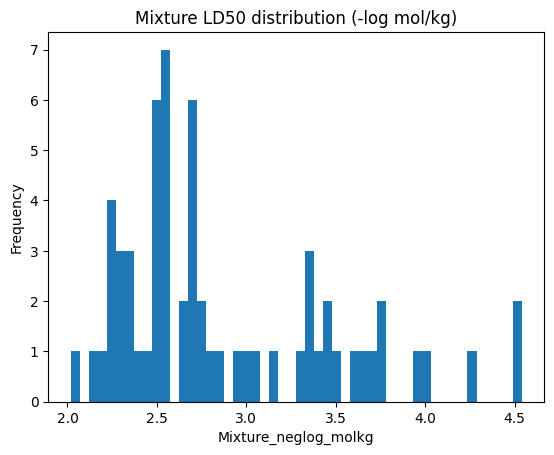

In [98]:
print("Mixture dataset size:", len(mixture_model_ready))
print(mixture_model_ready["Mixture_neglog_molkg"].describe())

plt.hist(mixture_model_ready["Mixture_neglog_molkg"], bins=50)
plt.title("Mixture LD50 distribution (-log mol/kg)")
plt.xlabel("Mixture_neglog_molkg")
plt.ylabel("Frequency")
plt.show()

| neglog_molkg range | Interpretation          |
| ------------------ | ----------------------- |
| **< 1.5**          | very low toxicity       |
| **1.5 to 2.0**     | low toxicity            |
| **2.0 to 2.5**     | moderate toxicity       |
| **2.5 to 3.0**     | high toxicity           |
| **3.0 to 3.5**     | very high toxicity      |
| **> 3.5**          | extremely high toxicity |


NOTES:

### Justification of median aggregation

In this dataset, the same chemical often appears multiple times with different LD₅₀ values. These variations arise due to differences in experimental conditions such as study source, sex of the test animals, reporting format, and measurement uncertainty. As a result, a single compound may have several reported toxicity values.

To obtain a single representative value per compound, duplicate records are aggregated using the median LD₅₀.

The median is preferred over the mean for the following reasons:

- Robust to outliers: Toxicity datasets frequently contain extreme values due to experimental variability or reporting differences. The median reduces the influence of such outliers.

- More stable central tendency: It better represents the typical toxicity level when the distribution is skewed, which is common in LD₅₀ data.

- Preserves biological realism: Median aggregation avoids overestimating or underestimating toxicity due to a few extreme measurements.

Basicallu using the median of the already transformed -log₁₀(mol/kg) values is equivalent to taking the median on the log scale, which is a standard practice in toxicology (Karmaus et al., 2022; Journal of Cheminformatics). When multiple measurements are available, the median provides a stable central estimate without being unduly influenced by extreme values.